In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Telco_Churn_Dataset.csv")

In [3]:
df.shape
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()

In [6]:
df_master = df.copy()

In [7]:
df_master["SeniorCitizen"] = df_master["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [8]:
df['TotalCharges'].dtype
df['TotalCharges'].isna().sum()

np.int64(0)

In [9]:
df.head(50)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [11]:
df["TotalCharges"].dtypes

dtype('float64')

In [12]:
original_dtypes = df_master.dtypes.to_dict()

In [13]:
df_master.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.shape

(7032, 21)

In [15]:
import numpy as np
import pandas as pd

def missingness_injection(df, missing_rate, random_state=42, excluded_cols=('customerID', 'Churn')):
    """
    Inject MCAR missingness at an exact proportion of all eligible cells (no duplicates).
    """
    df_missing = df.copy()

    # Eligible columns
    eligible_cols = [c for c in df_missing.columns if c not in excluded_cols]

    n_rows = df_missing.shape[0]
    n_cols = len(eligible_cols)
    total_cells = n_rows * n_cols
    n_missing = int(round(total_cells * missing_rate))

    rng = np.random.default_rng(random_state)
    chosen = rng.choice(total_cells, size=n_missing, replace=False)

    # Map flat indices -> (row, col within eligible_cols)
    row_idx = chosen // n_cols
    col_idx = chosen % n_cols

    # Convert to absolute column positions in df_missing
    col_positions = [df_missing.columns.get_loc(eligible_cols[i]) for i in col_idx]

    # Correct vectorized assignment using paired indices
    arr = df_missing.to_numpy(copy=True)
    arr[row_idx, col_positions] = np.nan
    df_missing = pd.DataFrame(arr, columns=df_missing.columns)

    return df_missing

In [16]:
def restore_dtypes(df, dtype_map):
    df_restored = df.copy()
    
    for col, dtype in dtype_map.items():
        if col in df_restored.columns:
            try:
                df_restored[col] = df_restored[col].astype(dtype)
            except:
                # If integer column now has NaN then convert to float
                if "int" in str(dtype):
                    df_restored[col] = df_restored[col].astype(float)
    
    return df_restored

In [17]:
# inject missingness
df_2pct  = missingness_injection(df_master, 0.02, random_state=42)
df_5pct  = missingness_injection(df_master, 0.05, random_state=42)
df_10pct = missingness_injection(df_master, 0.10, random_state=42)

# restore dtypes
df_2pct  = restore_dtypes(df_2pct, original_dtypes)
df_5pct  = restore_dtypes(df_5pct, original_dtypes)
df_10pct = restore_dtypes(df_10pct, original_dtypes)

print(df_2pct.isna().sum().sum())
print(df_5pct.isna().sum().sum())
print(df_10pct.isna().sum().sum())

2672
6680
13361


In [18]:
df_master.to_csv("df_master.csv", index=False)
df_2pct.to_csv("df_2pct.csv", index=False)
df_5pct.to_csv("df_5pct.csv", index=False)
df_10pct.to_csv("df_10pct.csv", index=False)

In [19]:
df_2pct.dtypes

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [20]:
df_master['customerID'].duplicated().sum()

np.int64(0)

In [21]:
df_master.duplicated().sum()

np.int64(0)

In [22]:
df_master[df_master['customerID'].duplicated(keep=False)].sort_values('customerID')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [23]:
df_master.drop(columns='customerID').duplicated().sum()

np.int64(22)

## Statistical Imputation

### Separate Numerical and Categorical Columns

In [24]:
num_cols = df_master.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_master.select_dtypes(include=["object"]).columns.tolist()

exclude = ["customerID", "Churn"]
num_cols = [c for c in num_cols if c not in exclude]
cat_cols = [c for c in cat_cols if c not in exclude]

In [25]:
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Numerical and Categorical Imputation (mean or median + mode combination)

In [26]:
def impute_mean(df):
    d = df.copy()
    for col in num_cols:
        d[col] = d[col].fillna(d[col].mean())
    for col in cat_cols:
        d[col] = d[col].fillna(d[col].mode()[0])
    return d

def impute_median(df):
    d = df.copy()
    for col in num_cols:
        d[col] = d[col].fillna(d[col].median())
    for col in cat_cols:
        d[col] = d[col].fillna(d[col].mode()[0])
    return d

### Random Value Imputation

In [27]:
def impute_random_rowwise(df, random_state=42):
    rng = np.random.default_rng(random_state)
    d = df.copy()
    
    complete_rows = d.dropna()
    
    for idx in d.index:
        if d.loc[idx].isna().any():
            donor = complete_rows.sample(n=1, random_state=rng.integers(0, 1e9)).iloc[0]
            for col in d.columns:
                if pd.isna(d.loc[idx, col]):
                    d.loc[idx, col] = donor[col]
    
    return d

In [28]:
df_2pct_mean   = impute_mean(df_2pct)
df_2pct_median = impute_median(df_2pct)
df_2pct_random = impute_random_rowwise(df_2pct)

df_5pct_mean   = impute_mean(df_5pct)
df_5pct_median = impute_median(df_5pct)
df_5pct_random = impute_random_rowwise(df_5pct)

df_10pct_mean   = impute_mean(df_10pct)
df_10pct_median = impute_median(df_10pct)
df_10pct_random = impute_random_rowwise(df_10pct)

In [29]:
print(df_2pct_mean.isna().sum().sum())
print(df_2pct_median.isna().sum().sum())
print(df_2pct_random.isna().sum().sum())

0
0
0


### Recontruction Error Evaluation

### Numerical reconstruction percentage error (MAPE & RMSPE)

In [30]:
def reconstruction_percentage_errors(original, imputed, mask, num_cols):
    perc_errors = []

    for col in num_cols:
        m = mask[col].to_numpy()
        if m.sum() == 0:
            continue

        true_vals = original[col].to_numpy(dtype=float)[m]
        imp_vals  = imputed[col].to_numpy(dtype=float)[m]

        # avoid division by zero
        nonzero = true_vals != 0
        true_vals = true_vals[nonzero]
        imp_vals  = imp_vals[nonzero]

        perc = (true_vals - imp_vals) / true_vals
        perc_errors.append(perc)

    if not perc_errors:
        return np.nan, np.nan

    perc_errors = np.concatenate(perc_errors)

    mape  = np.mean(np.abs(perc_errors))
    rmspe = np.sqrt(np.mean(perc_errors**2))
    return mape, rmspe

## 2%, 5%, and 10% computation

In [31]:
# Make all indices consistent
df_master = df_master.reset_index(drop=True)

df_5pct = df_5pct.reset_index(drop=True)
df_10pct = df_10pct.reset_index(drop=True)

df_5pct_mean = df_5pct_mean.reset_index(drop=True)
df_5pct_median = df_5pct_median.reset_index(drop=True)
df_5pct_random = df_5pct_random.reset_index(drop=True)

df_10pct_mean = df_10pct_mean.reset_index(drop=True)
df_10pct_median = df_10pct_median.reset_index(drop=True)
df_10pct_random = df_10pct_random.reset_index(drop=True)

# Rebuild masks AFTER index reset
mask_5pct  = df_5pct.isna()
mask_10pct = df_10pct.isna()

# Quick sanity checks (should all be True)
print(df_master.shape == df_5pct.shape == df_5pct_mean.shape)
print(df_master.columns.equals(df_5pct.columns), df_master.columns.equals(df_5pct_mean.columns))
print(df_master.index.equals(df_5pct.index), df_master.index.equals(df_5pct_mean.index))

True
True True
True True


In [32]:
mask_2pct  = df_2pct.isna()
mask_5pct  = df_5pct.isna()
mask_10pct = df_10pct.isna()

In [33]:
mape_mean_5, rmspe_mean_5   = reconstruction_percentage_errors(df_master, df_5pct_mean, mask_5pct, num_cols)
mape_median_5, rmspe_median_5 = reconstruction_percentage_errors(df_master, df_5pct_median, mask_5pct, num_cols)
mape_rand_5, rmspe_rand_5   = reconstruction_percentage_errors(df_master, df_5pct_random, mask_5pct, num_cols)

mape_mean_10, rmspe_mean_10   = reconstruction_percentage_errors(df_master, df_10pct_mean, mask_10pct, num_cols)
mape_median_10, rmspe_median_10 = reconstruction_percentage_errors(df_master, df_10pct_median, mask_10pct, num_cols)
mape_rand_10, rmspe_rand_10   = reconstruction_percentage_errors(df_master, df_10pct_random, mask_10pct, num_cols)

In [34]:
mape_mean_2, rmspe_mean_2   = reconstruction_percentage_errors(df_master, df_2pct_mean, mask_2pct, num_cols)
mape_median_2, rmspe_median_2 = reconstruction_percentage_errors(df_master, df_2pct_median, mask_2pct, num_cols)
mape_rand_2, rmspe_rand_2   = reconstruction_percentage_errors(df_master, df_2pct_random, mask_2pct, num_cols)

In [35]:
print("2% MAPE:", mape_mean_2, mape_median_2, mape_rand_2)
print("2% RMSPE:", rmspe_mean_2, rmspe_median_2, rmspe_rand_2)

print("5% MAPE:", mape_mean_5, mape_median_5, mape_rand_5)
print("5% RMSPE:", rmspe_mean_5, rmspe_median_5, rmspe_rand_5)

print("10% MAPE:", mape_mean_10, mape_median_10, mape_rand_10)
print("10% RMSPE:", rmspe_mean_10, rmspe_median_10, rmspe_rand_10)

2% MAPE: 5.386446655082307 3.829316731762275 4.793728830732702
2% RMSPE: 15.597089505915134 10.309091305626463 17.00054425747622
5% MAPE: 4.458598771237831 3.2806051753933474 4.58681779326376
5% RMSPE: 12.949064863466814 8.829045346881648 17.878604320419782
10% MAPE: 4.9575500703771835 3.551649027385977 5.111330956535807
10% RMSPE: 15.092831455549005 9.951227263974951 21.59344528669709


### Categorical reconstruction accuracy

In [36]:
def reconstruction_accuracy(original, imputed, mask, cat_cols):
    correct = 0
    total = 0
    
    for col in cat_cols:
        m = mask[col]
        if m.sum() == 0:
            continue
        
        true_vals = original.loc[m, col]
        imp_vals  = imputed.loc[m, col]
        
        correct += (true_vals == imp_vals).sum()
        total += m.sum()
    
    return correct / total if total > 0 else np.nan

In [37]:
acc_mean_2   = reconstruction_accuracy(df_master, df_2pct_mean, mask_2pct, cat_cols)
acc_median_2 = reconstruction_accuracy(df_master, df_2pct_median, mask_2pct, cat_cols)
acc_rand_2   = reconstruction_accuracy(df_master, df_2pct_random, mask_2pct, cat_cols)

acc_mean_5   = reconstruction_accuracy(df_master, df_5pct_mean, mask_5pct, cat_cols)
acc_median_5 = reconstruction_accuracy(df_master, df_5pct_median, mask_5pct, cat_cols)
acc_rand_5   = reconstruction_accuracy(df_master, df_5pct_random, mask_5pct, cat_cols)

acc_mean_10   = reconstruction_accuracy(df_master, df_10pct_mean, mask_10pct, cat_cols)
acc_median_10 = reconstruction_accuracy(df_master, df_10pct_median, mask_10pct, cat_cols)
acc_rand_10   = reconstruction_accuracy(df_master, df_10pct_random, mask_10pct, cat_cols)

In [38]:
print(acc_mean_2, acc_median_2, acc_rand_2)
print(acc_mean_5, acc_median_5, acc_rand_5)
print(acc_mean_10, acc_median_10, acc_rand_10)

0.5341009743135519 0.5341009743135519 0.4455270150575731
0.5292656970556935 0.5292656970556935 0.44998226321390566
0.5371805147386232 0.5371805147386232 0.4555169650013358


### Predictive Evaluation

In [39]:
from sklearn.preprocessing import LabelEncoder

def prepare_ml(df, cat_cols):
    df_ml = df.copy()
    
    # encode categorical features + target
    for col in cat_cols + ['Churn']:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col])
    
    X = df_ml.drop(columns=['customerID', 'Churn'])
    y = df_ml['Churn']
    
    return X, y

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(df, cat_cols):
    X, y = prepare_ml(df, cat_cols)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    
    return acc, f1

In [41]:
# 2%
acc_mean_2_ml, f1_mean_2 = evaluate_model(df_2pct_mean, cat_cols)
acc_median_2_ml, f1_median_2 = evaluate_model(df_2pct_median, cat_cols)
acc_rand_2_ml, f1_rand_2 = evaluate_model(df_2pct_random, cat_cols)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [42]:
# 5%
acc_mean_5_ml, f1_mean_5 = evaluate_model(df_5pct_mean, cat_cols)
acc_median_5_ml, f1_median_5 = evaluate_model(df_5pct_median, cat_cols)
acc_rand_5_ml, f1_rand_5 = evaluate_model(df_5pct_random, cat_cols)

# 10%
acc_mean_10_ml, f1_mean_10 = evaluate_model(df_10pct_mean, cat_cols)
acc_median_10_ml, f1_median_10 = evaluate_model(df_10pct_median, cat_cols)
acc_rand_10_ml, f1_rand_10 = evaluate_model(df_10pct_random, cat_cols)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [43]:
print("2%:", acc_mean_2_ml, acc_median_2_ml, acc_rand_2_ml)
print("2% F1:", f1_mean_2, f1_median_2, f1_rand_2)

print("5%:", acc_mean_5_ml, acc_median_5_ml, acc_rand_5_ml)
print("5% F1:", f1_mean_5, f1_median_5, f1_rand_5)

print("10%:", acc_mean_10_ml, acc_median_10_ml, acc_rand_10_ml)
print("10% F1:", f1_mean_10, f1_median_10, f1_rand_10)

2%: 0.7910447761194029 0.7896233120113717 0.7846481876332623
2% F1: 0.5859154929577465 0.5819209039548022 0.5714285714285714
5%: 0.7860696517412935 0.7860696517412935 0.7860696517412935
5% F1: 0.5656565656565656 0.5669064748201439 0.5592972181551976
10%: 0.7810945273631841 0.7810945273631841 0.7846481876332623
10% F1: 0.5523255813953488 0.553623188405797 0.5576642335766423


# Machine Learning Imputations (KNN)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

def knn_impute(df, cat_cols, id_col="customerID", target_col="Churn", n_neighbors=5):
    # separate ID + target
    ids = df[id_col]
    y   = df[target_col]

    d = df.drop(columns=[id_col, target_col]).copy()

    # encode categorical columns
    cat_maps = {}  # store reverse mapping for decoding
    for col in cat_cols:
        if col in d.columns:
            # categories from NON-missing values only
            categories = pd.Series(d[col].dropna().unique()).astype(str).tolist()
            cat_maps[col] = categories

            forward = {cat: i for i, cat in enumerate(categories)}

            # map keeps NaN as NaN
            d[col] = d[col].astype(object).map(lambda x: forward.get(str(x), np.nan) if pd.notna(x) else np.nan)

    # scale
    scaler = StandardScaler()
    scaled = scaler.fit_transform(d)

    # KNN impute
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_scaled = imputer.fit_transform(scaled)

    # inverse scale
    imputed = scaler.inverse_transform(imputed_scaled)
    imputed = pd.DataFrame(imputed, columns=d.columns, index=df.index)

    # decode categoricals back to labels
    for col, categories in cat_maps.items():
        # imputed codes -> nearest integer category index
        codes = np.rint(imputed[col]).astype(int)

        # clamp to valid range
        codes = np.clip(codes, 0, len(categories) - 1)

        imputed[col] = pd.Series(codes, index=imputed.index).map(lambda i: categories[i]).astype(str).str.strip()

    # restore ID + target
    imputed[id_col] = ids
    imputed[target_col] = y

    # restore original order
    imputed = imputed[df.columns]
    return imputed

In [45]:
k_values = [3, 5, 7, 10]

results = []

for k in k_values:
    df_knn_k = knn_impute(df_5pct, cat_cols, n_neighbors=k)
    
    mape, rmspe = reconstruction_percentage_errors(df_master, df_knn_k, mask_5pct, num_cols)
    acc_cat = reconstruction_accuracy(df_master, df_knn_k, mask_5pct, cat_cols)
    acc_ml, f1_ml = evaluate_model(df_knn_k, cat_cols)
    
    results.append({
        "K": k,
        "MAPE": mape,
        "RMSPE": rmspe,
        "CatAcc": acc_cat,
        "ML_Acc": acc_ml,
        "F1": f1_ml
    })

results_df = pd.DataFrame(results)
print(results_df)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

    K      MAPE     RMSPE    CatAcc    ML_Acc        F1
0   3  0.606924  2.023634  0.706988  0.792466  0.585227
1   5  0.627859  1.947867  0.724548  0.789623  0.579545
2   7  0.651969  2.051339  0.720468  0.790334  0.582744
3  10  0.687759  2.136358  0.725612  0.791756  0.584397


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
df_2pct_knn  = knn_impute(df_2pct, cat_cols)
df_5pct_knn  = knn_impute(df_5pct, cat_cols)
df_10pct_knn = knn_impute(df_10pct, cat_cols)

In [47]:
mape_knn_2, rmspe_knn_2 = reconstruction_percentage_errors(df_master, df_2pct_knn, mask_2pct, num_cols)
acc_knn_2 = reconstruction_accuracy(df_master, df_2pct_knn, mask_2pct, cat_cols)

In [48]:
mape_knn_5, rmspe_knn_5 = reconstruction_percentage_errors(df_master, df_5pct_knn, mask_5pct, num_cols)
acc_knn_5 = reconstruction_accuracy(df_master, df_5pct_knn, mask_5pct, cat_cols)

In [49]:
mape_knn_10, rmspe_knn_10 = reconstruction_percentage_errors(df_master, df_10pct_knn, mask_10pct, num_cols)
acc_knn_10 = reconstruction_accuracy(df_master, df_10pct_knn, mask_10pct, cat_cols)

In [50]:
acc_knn_cat_2 = reconstruction_accuracy(df_master, df_2pct_knn, mask_2pct, cat_cols)
acc_knn_cat_5 = reconstruction_accuracy(df_master, df_5pct_knn, mask_5pct, cat_cols)
acc_knn_cat_10 = reconstruction_accuracy(df_master, df_10pct_knn, mask_10pct, cat_cols)

In [51]:
acc_knn_2_ml, f1_knn_2 = evaluate_model(df_2pct_knn, cat_cols)
acc_knn_5_ml, f1_knn_5 = evaluate_model(df_5pct_knn, cat_cols)
acc_knn_10_ml, f1_knn_10 = evaluate_model(df_10pct_knn, cat_cols)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [52]:
print("KNN 2% MAPE/RMSPE:", mape_knn_2, rmspe_knn_2)
print("KNN 5% MAPE/RMSPE:", mape_knn_5, rmspe_knn_5)
print("KNN 10% MAPE/RMSPE:", mape_knn_10, rmspe_knn_10)

print("KNN categorical acc:", acc_knn_cat_2, acc_knn_cat_5, acc_knn_cat_10)

print("KNN predictive acc:", acc_knn_2_ml, acc_knn_5_ml, acc_knn_10_ml)
print("KNN predictive F1:", f1_knn_2, f1_knn_5, f1_knn_10)

KNN 2% MAPE/RMSPE: 0.6016409355400346 1.880764197668124
KNN 5% MAPE/RMSPE: 0.6278588723094234 1.9478673273468428
KNN 10% MAPE/RMSPE: 0.7817445365933654 2.6262390274380563
KNN categorical acc: 0.7214348981399469 0.7245477119545938 0.7168937572357289
KNN predictive acc: 0.7924662402274343 0.7896233120113717 0.8009950248756219
KNN predictive F1: 0.5898876404494382 0.5795454545454546 0.6


In [53]:
col = cat_cols[0]

m = mask_2pct[col]

print("True:", df_master.loc[m, col].unique()[:10])
print("KNN :", df_2pct_knn.loc[m, col].unique()[:10])

True: ['Female' 'Male']
KNN : ['Male' 'Female']


In [54]:
df_2pct_knn = knn_impute(df_2pct, cat_cols, n_neighbors=5)
print(df_2pct_knn.isna().sum().sum())

0


# ML Imputations (MICE & Custom ML Imputer)

In [55]:
df_master = df_master.reset_index(drop=True)

df_2pct = df_2pct.reset_index(drop=True)
df_5pct = df_5pct.reset_index(drop=True)
df_10pct = df_10pct.reset_index(drop=True)

mask_2pct = df_2pct.isna()
mask_5pct = df_5pct.isna()
mask_10pct = df_10pct.isna()

# Encode categoricals for MICE/ ML imputers

In [56]:
''' Converts categories to integer codes.
Keeps missing values as NaN'''
def encode_categoricals_nan_safe(df, cat_cols, exclude_cols=("customerID","Churn")):
    d = df.copy()
    cat_maps = {}

    for col in cat_cols:
        if col in exclude_cols: 
            continue
        if col in d.columns:
            categories = pd.Series(d[col].dropna().unique()).astype(str).tolist()
            cat_maps[col] = categories
            forward = {cat: i for i, cat in enumerate(categories)}

            # map values; keep NaN as NaN
            d[col] = d[col].astype(object).map(
                lambda x: forward.get(str(x), np.nan) if pd.notna(x) else np.nan
            )

    return d, cat_maps

def decode_categoricals_from_codes(df_encoded, cat_maps):
    d = df_encoded.copy()
    for col, categories in cat_maps.items():
        # round + clamp, then map back to labels
        codes = np.rint(d[col]).astype(int)
        codes = np.clip(codes, 0, len(categories)-1)
        d[col] = pd.Series(codes, index=d.index).map(lambda i: categories[i]).astype(str).str.strip()
    return d

## MICE Imputation

In [57]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler

def mice_impute(df, cat_cols, id_col="customerID", target_col="Churn", random_state=42):
    # separate ID + target
    ids = df[id_col]
    y   = df[target_col]

    X = df.drop(columns=[id_col, target_col]).copy()

    # encode categoricals (NaN-safe)
    X_enc, cat_maps = encode_categoricals_nan_safe(X, cat_cols, exclude_cols=())

    # scale helps iterative models behave better
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_enc)

    # MICE with ExtraTreesRegressor tends to work well on non-linear data
    estimator = ExtraTreesRegressor(
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1
    )

    imp = IterativeImputer(
        estimator=estimator,
        max_iter=10,
        random_state=random_state,
        sample_posterior=False
    )

    X_imp_scaled = imp.fit_transform(X_scaled)
    X_imp = scaler.inverse_transform(X_imp_scaled)
    X_imp = pd.DataFrame(X_imp, columns=X_enc.columns, index=df.index)

    # decode categoricals back
    X_imp = decode_categoricals_from_codes(X_imp, cat_maps)

    # restore ID + target
    out = pd.concat([ids, X_imp, y], axis=1)
    out = out[df.columns]  # original order
    return out

## Custom ML imputer

In [58]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

def get_models(model_type="rf", random_state=42):
    model_type = model_type.lower()

    if model_type == "rf":
        reg = RandomForestRegressor(n_estimators=200, random_state=random_state, n_jobs=-1)
        clf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)

    elif model_type == "mlp":
        reg = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=random_state)
        clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=random_state)

    elif model_type == "xgb":
        try:
            from xgboost import XGBRegressor, XGBClassifier
            reg = XGBRegressor(
                n_estimators=300, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, random_state=random_state
            )
            clf = XGBClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, random_state=random_state,
                eval_metric="logloss"
            )
        except ImportError:
            # fallback (still strong)
            reg = HistGradientBoostingRegressor(random_state=random_state)
            clf = HistGradientBoostingClassifier(random_state=random_state)

    else:
        raise ValueError("model_type must be one of: 'rf', 'xgb', 'mlp'")

    return reg, clf

In [59]:
from sklearn.impute import SimpleImputer

def custom_ml_impute(df, cat_cols, model_type="rf", id_col="customerID", target_col="Churn", random_state=42):
    ids = df[id_col]
    y   = df[target_col]

    X = df.drop(columns=[id_col, target_col]).copy()

    # encode categoricals
    X_enc, cat_maps = encode_categoricals_nan_safe(X, cat_cols, exclude_cols=())

    # initial simple fill for predictors (so models can train)
    # numeric cols in encoded frame are all float now, but categorical-coded are numeric too.
    # We'll treat columns that were categorical originally separately.
    cat_encoded_cols = [c for c in cat_maps.keys() if c in X_enc.columns]
    num_like_cols = [c for c in X_enc.columns if c not in cat_encoded_cols]

    # fill numeric-like with median
    imp_num = SimpleImputer(strategy="median")
    X_enc[num_like_cols] = imp_num.fit_transform(X_enc[num_like_cols])

    # fill categorical-coded with most_frequent (mode)
    imp_cat = SimpleImputer(strategy="most_frequent")
    X_enc[cat_encoded_cols] = imp_cat.fit_transform(X_enc[cat_encoded_cols])

    # now build models
    reg, clf = get_models(model_type=model_type, random_state=random_state)

    # impute each column that had missing in original X (not the prefilled X_enc)
    for col in X.columns:
        miss_mask = X[col].isna()
        if miss_mask.sum() == 0:
            continue

        # prepare train/test matrices using other columns
        feature_cols = [c for c in X_enc.columns if c != col]

        X_train = X_enc.loc[~miss_mask, feature_cols]
        X_pred  = X_enc.loc[miss_mask, feature_cols]

        # target values
        y_train_raw = X_enc.loc[~miss_mask, col]

        # decide if column is categorical
        if col in cat_maps:  # categorical-coded
            model = clf
            y_train = y_train_raw.astype(int)
            model.fit(X_train, y_train)
            y_hat = model.predict(X_pred).astype(int)
            X_enc.loc[miss_mask, col] = y_hat
        else:
            model = reg
            y_train = y_train_raw.astype(float)
            model.fit(X_train, y_train)
            y_hat = model.predict(X_pred).astype(float)
            X_enc.loc[miss_mask, col] = y_hat

    # decode categoricals back to original labels
    X_out = decode_categoricals_from_codes(X_enc, cat_maps)

    out = pd.concat([ids, X_out, y], axis=1)
    out = out[df.columns]
    return out

In [60]:
df_2pct_mice  = mice_impute(df_2pct, cat_cols)
df_5pct_mice  = mice_impute(df_5pct, cat_cols)
df_10pct_mice = mice_impute(df_10pct, cat_cols)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [61]:
# Random Forest custom imputer
df_2pct_rf  = custom_ml_impute(df_2pct, cat_cols, model_type="rf")
df_5pct_rf  = custom_ml_impute(df_5pct, cat_cols, model_type="rf")
df_10pct_rf = custom_ml_impute(df_10pct, cat_cols, model_type="rf")

# XGBoost custom imputer (or fallback)
df_2pct_xgb  = custom_ml_impute(df_2pct, cat_cols, model_type="xgb")
df_5pct_xgb  = custom_ml_impute(df_5pct, cat_cols, model_type="xgb")
df_10pct_xgb = custom_ml_impute(df_10pct, cat_cols, model_type="xgb")

# Feedforward neural net (MLP) custom imputer
df_2pct_mlp  = custom_ml_impute(df_2pct, cat_cols, model_type="mlp")
df_5pct_mlp  = custom_ml_impute(df_5pct, cat_cols, model_type="mlp")
df_10pct_mlp = custom_ml_impute(df_10pct, cat_cols, model_type="mlp")

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [69]:
mape_mice_5, rmspe_mice_5 = reconstruction_percentage_errors(
    df_master,
    df_5pct_mice,
    mask_5pct,
    num_cols
)

print("MICE 5% MAPE:", mape_mice_5)
print("MICE 5% RMSPE:", rmspe_mice_5)

MICE 5% MAPE: 0.15153560318690093
MICE 5% RMSPE: 1.3500353602095976


In [70]:
acc_mice_cat_5 = reconstruction_accuracy(
    df_master,
    df_5pct_mice,
    mask_5pct,
    cat_cols
)

print("MICE 5% Categorical Accuracy:", acc_mice_cat_5)

MICE 5% Categorical Accuracy: 0.7736786094359702


In [71]:
acc_mice_ml_5, f1_mice_5 = evaluate_model(df_5pct_mice, cat_cols)

print("MICE 5% Predictive Accuracy:", acc_mice_ml_5)
print("MICE 5% F1:", f1_mice_5)

MICE 5% Predictive Accuracy: 0.7931769722814499
MICE 5% F1: 0.5918653576437588


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
df_2pct_mice  = mice_impute(df_2pct, cat_cols)
df_10pct_mice = mice_impute(df_10pct, cat_cols)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [74]:
mape_mice_2, rmspe_mice_2 = reconstruction_percentage_errors(
    df_master, df_2pct_mice, mask_2pct, num_cols
)

mape_mice_10, rmspe_mice_10 = reconstruction_percentage_errors(
    df_master, df_10pct_mice, mask_10pct, num_cols
)

print("MICE 2%:", mape_mice_2, rmspe_mice_2)
print("MICE 10%:", mape_mice_10, rmspe_mice_10)

MICE 2%: 0.0334042383336804 0.06765243255050565
MICE 10%: 0.32508667254383733 2.225673998588929


In [75]:
acc_mice_cat_2 = reconstruction_accuracy(
    df_master, df_2pct_mice, mask_2pct, cat_cols
)

acc_mice_cat_10 = reconstruction_accuracy(
    df_master, df_10pct_mice, mask_10pct, cat_cols
)

print("MICE CatAcc 2%:", acc_mice_cat_2)
print("MICE CatAcc 10%:", acc_mice_cat_10)

MICE CatAcc 2%: 0.7896368467670505
MICE CatAcc 10%: 0.7658740760530769


In [76]:
acc_mice_ml_2, f1_mice_2 = evaluate_model(df_2pct_mice, cat_cols)
acc_mice_ml_10, f1_mice_10 = evaluate_model(df_10pct_mice, cat_cols)

print("MICE ML 2%:", acc_mice_ml_2, f1_mice_2)
print("MICE ML 10%:", acc_mice_ml_10, f1_mice_10)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MICE ML 2%: 0.7924662402274343 0.5887323943661972
MICE ML 10%: 0.8002842928216063 0.6036671368124118


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
df_5pct_rf = custom_ml_impute(
    df_5pct,
    cat_cols,
    model_type="rf"
)

In [78]:
mape_rf_5, rmspe_rf_5 = reconstruction_percentage_errors(
    df_master, df_5pct_rf, mask_5pct, num_cols
)

acc_rf_cat_5 = reconstruction_accuracy(
    df_master, df_5pct_rf, mask_5pct, cat_cols
)

acc_rf_ml_5, f1_rf_5 = evaluate_model(df_5pct_rf, cat_cols)

print("RF 5%:", mape_rf_5, rmspe_rf_5)
print("RF CatAcc 5%:", acc_rf_cat_5)
print("RF ML 5%:", acc_rf_ml_5, f1_rf_5)

RF 5%: 0.1217248912073107 0.857640779946034
RF CatAcc 5%: 0.7752749201844625
RF ML 5%: 0.7967306325515281 0.5949008498583569


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [79]:
df_2pct_rf  = custom_ml_impute(df_2pct, cat_cols, model_type="rf")
df_10pct_rf = custom_ml_impute(df_10pct, cat_cols, model_type="rf")

# Reconstruction
mape_rf_2, rmspe_rf_2 = reconstruction_percentage_errors(df_master, df_2pct_rf, mask_2pct, num_cols)
mape_rf_10, rmspe_rf_10 = reconstruction_percentage_errors(df_master, df_10pct_rf, mask_10pct, num_cols)

# Categorical
acc_rf_cat_2 = reconstruction_accuracy(df_master, df_2pct_rf, mask_2pct, cat_cols)
acc_rf_cat_10 = reconstruction_accuracy(df_master, df_10pct_rf, mask_10pct, cat_cols)

# Predictive
acc_rf_ml_2, f1_rf_2 = evaluate_model(df_2pct_rf, cat_cols)
acc_rf_ml_10, f1_rf_10 = evaluate_model(df_10pct_rf, cat_cols)

print("RF 2%:", mape_rf_2, rmspe_rf_2, acc_rf_cat_2, acc_rf_ml_2, f1_rf_2)
print("RF 10%:", mape_rf_10, rmspe_rf_10, acc_rf_cat_10, acc_rf_ml_10, f1_rf_10)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RF 2%: 0.03225664869595493 0.06749847032590577 0.7967227635075288 0.7924662402274343 0.5910364145658263
RF 10%: 0.27967246558413034 1.8298237856383543 0.7695253361830974 0.8017057569296375 0.6053748231966054


## XGBoost Custom Imputer (5%)

In [80]:
df_5pct_xgb = custom_ml_impute(
    df_5pct,
    cat_cols,
    model_type="xgb"
)

mape_xgb_5, rmspe_xgb_5 = reconstruction_percentage_errors(
    df_master, df_5pct_xgb, mask_5pct, num_cols
)

acc_xgb_cat_5 = reconstruction_accuracy(
    df_master, df_5pct_xgb, mask_5pct, cat_cols
)

acc_xgb_ml_5, f1_xgb_5 = evaluate_model(df_5pct_xgb, cat_cols)

print("XGB 5%:", mape_xgb_5, rmspe_xgb_5)
print("XGB CatAcc 5%:", acc_xgb_cat_5)
print("XGB ML 5%:", acc_xgb_ml_5, f1_xgb_5)

XGB 5%: 0.13906645924554978 0.9947515604348919
XGB CatAcc 5%: 0.8066690315714793
XGB ML 5%: 0.7938877043354655 0.5903954802259888


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [81]:
df_5pct_mlp = custom_ml_impute(
    df_5pct,
    cat_cols,
    model_type="mlp"
)

mape_mlp_5, rmspe_mlp_5 = reconstruction_percentage_errors(
    df_master, df_5pct_mlp, mask_5pct, num_cols
)

acc_mlp_cat_5 = reconstruction_accuracy(
    df_master, df_5pct_mlp, mask_5pct, cat_cols
)

acc_mlp_ml_5, f1_mlp_5 = evaluate_model(df_5pct_mlp, cat_cols)

print("MLP 5%:", mape_mlp_5, rmspe_mlp_5)
print("MLP CatAcc 5%:", acc_mlp_cat_5)
print("MLP ML 5%:", acc_mlp_ml_5, f1_mlp_5)

C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP 5%: 0.31816225711678936 1.5035751342986639
MLP CatAcc 5%: 0.6614047534586733
MLP ML 5%: 0.7931769722814499 0.5907172995780591


C:\Users\drero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
final_results = pd.DataFrame({

    "Method": ["Median", "KNN", "MICE", "RF", "XGB", "MLP"],

    # ---- 2% ----
    "MAPE_2%": [
        mape_median_2,
        mape_knn_2,
        mape_mice_2,
        mape_rf_2,
        np.nan,  # XGB not run at 2%
        np.nan   # MLP not run at 2%
    ],

    "F1_2%": [
        f1_mean_2,
        f1_knn_2,
        f1_mice_2,
        f1_rf_2,
        np.nan,
        np.nan
    ],

    # ---- 5% ----
    "MAPE_5%": [
        mape_median_5,
        mape_knn_5,
        mape_mice_5,
        mape_rf_5,
        mape_xgb_5,
        mape_mlp_5
    ],

    "F1_5%": [
        f1_mean_5,
        f1_knn_5,
        f1_mice_5,
        f1_rf_5,
        f1_xgb_5,
        f1_mlp_5
    ],

    # ---- 10% ----
    "MAPE_10%": [
        mape_median_10,
        mape_knn_10,
        mape_mice_10,
        mape_rf_10,
        np.nan,
        np.nan
    ],

    "F1_10%": [
        f1_mean_10,
        f1_knn_10,
        f1_mice_10,
        f1_rf_10,
        np.nan,
        np.nan
    ],
})

print(final_results)

   Method   MAPE_2%     F1_2%   MAPE_5%     F1_5%  MAPE_10%    F1_10%
0  Median  3.829317  0.585915  3.280605  0.565657  3.551649  0.552326
1     KNN  0.601641  0.589888  0.627859  0.579545  0.781745  0.600000
2    MICE  0.033404  0.588732  0.151536  0.591865  0.325087  0.603667
3      RF  0.032257  0.591036  0.121725  0.594901  0.279672  0.605375
4     XGB       NaN       NaN  0.139066  0.590395       NaN       NaN
5     MLP       NaN       NaN  0.318162  0.590717       NaN       NaN


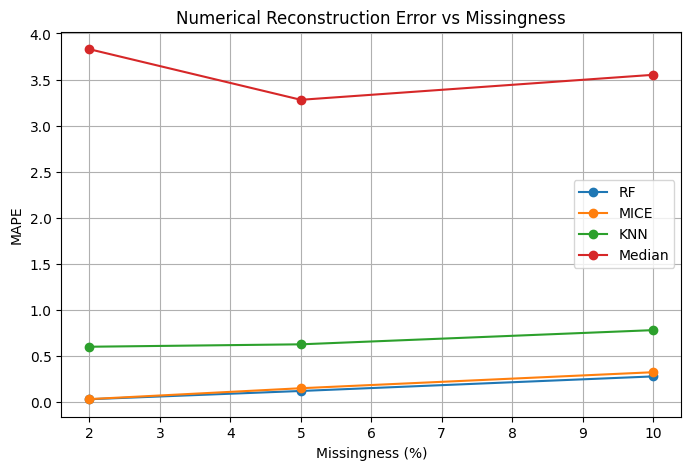

In [83]:
import matplotlib.pyplot as plt

missing_levels = [2, 5, 10]

rf_vals   = [mape_rf_2, mape_rf_5, mape_rf_10]
mice_vals = [mape_mice_2, mape_mice_5, mape_mice_10]
knn_vals  = [mape_knn_2, mape_knn_5, mape_knn_10]
median_vals = [mape_median_2, mape_median_5, mape_median_10]

plt.figure(figsize=(8,5))
plt.plot(missing_levels, rf_vals, marker='o', label="RF")
plt.plot(missing_levels, mice_vals, marker='o', label="MICE")
plt.plot(missing_levels, knn_vals, marker='o', label="KNN")
plt.plot(missing_levels, median_vals, marker='o', label="Median")

plt.xlabel("Missingness (%)")
plt.ylabel("MAPE")
plt.title("Numerical Reconstruction Error vs Missingness")
plt.legend()
plt.grid(True)
plt.show()

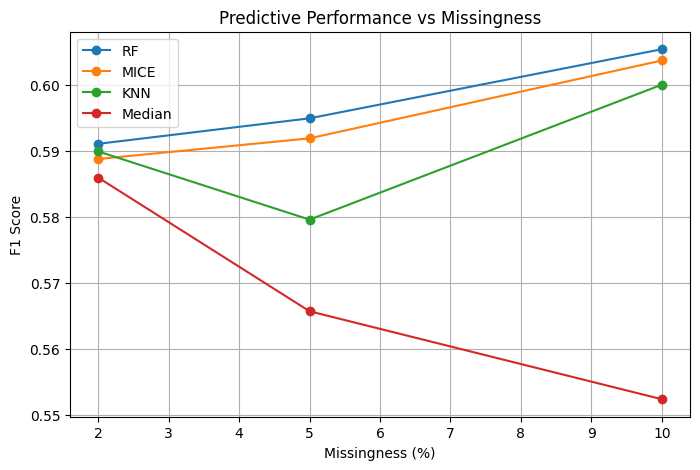

In [84]:
rf_f1   = [f1_rf_2, f1_rf_5, f1_rf_10]
mice_f1 = [f1_mice_2, f1_mice_5, f1_mice_10]
knn_f1  = [f1_knn_2, f1_knn_5, f1_knn_10]
median_f1 = [f1_mean_2, f1_mean_5, f1_mean_10]

plt.figure(figsize=(8,5))
plt.plot(missing_levels, rf_f1, marker='o', label="RF")
plt.plot(missing_levels, mice_f1, marker='o', label="MICE")
plt.plot(missing_levels, knn_f1, marker='o', label="KNN")
plt.plot(missing_levels, median_f1, marker='o', label="Median")

plt.xlabel("Missingness (%)")
plt.ylabel("F1 Score")
plt.title("Predictive Performance vs Missingness")
plt.legend()
plt.grid(True)
plt.show()